## Data Understanding
Before formulating the research question, we need to understand what each variable 
actually represents (data type, categories, missing values) so that our question 
and method choice are grounded in what the data can support.

In [10]:
import pandas as pd

df = pd.read_csv("../data/StressLevelDataset.csv")

df.head(5)

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


## Initial Data Understanding + Structure Sanity Check
Before selecting predictors, we check data types, missing values, unique 
categories, and  learning from the previous dataset. we immediately run 
a full correlation matrix to confirm the dataset actually has internal 
structure before investing further time in variable selection.

In [13]:
# Basic structure
print("Shape:", df.shape)
print()
print(df.dtypes)
print()
print("Missing values:\n", df.isna().sum())
print()
print("Duplicates:", df.duplicated().sum())
print()

# Unique values for the outcome and a few likely-categorical columns
for col in ["stress_level", "mental_health_history", "sleep_quality", "academic_performance"]:
    print(col, "→", df[col].unique())
print()

# Immediate sanity check: does the dataset have real internal structure?
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix.round(3))

Shape: (1100, 21)

anxiety_level                   int64
self_esteem                     int64
mental_health_history           int64
depression                      int64
headache                        int64
blood_pressure                  int64
sleep_quality                   int64
breathing_problem               int64
noise_level                     int64
living_conditions               int64
safety                          int64
basic_needs                     int64
academic_performance            int64
study_load                      int64
teacher_student_relationship    int64
future_career_concerns          int64
social_support                  int64
peer_pressure                   int64
extracurricular_activities      int64
bullying                        int64
stress_level                    int64
dtype: object

Missing values:
 anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
headache       

In [15]:
# Check which numeric code corresponds to low/high stress
# by cross-referencing with a variable we can reason about intuitively
print(df.groupby("stress_level")[["sleep_quality", "self_esteem", "anxiety_level"]].mean())

              sleep_quality  self_esteem  anxiety_level
stress_level                                           
0                  4.126005    25.252011       5.431635
1                  2.530726    19.262570      11.430168
2                  1.303523     8.780488      16.401084


## Multicollinearity Check Among Selected Predictors
Before finalizing the five Biopsychosocial predictors, we check pairwise 
correlations among them specifically. High inter-predictor correlation 
(multicollinearity) would need to be addressed before a combined model (Q7).

In [18]:
selected_vars = ["self_esteem", "sleep_quality", "safety", "academic_performance", "social_support"]
print(df[selected_vars].corr().round(3))

                      self_esteem  sleep_quality  safety  \
self_esteem                 1.000          0.663   0.644   
sleep_quality               0.663          1.000   0.658   
safety                      0.644          0.658   1.000   
academic_performance        0.639          0.671   0.643   
social_support              0.679          0.555   0.615   

                      academic_performance  social_support  
self_esteem                          0.639           0.679  
sleep_quality                        0.671           0.555  
safety                               0.643           0.615  
academic_performance                 1.000           0.568  
social_support                       0.568           1.000  


## Q1 - Research Question

**Research Question:** Are self-esteem, sleep quality, perceived safety, academic 
performance, and social support — representing the psychological, physiological, 
environmental, academic, and social dimensions of the Biopsychosocial Model 
(Engel, 1977) — associated with student stress level?

**Motivation:** Student stress is rarely driven by a single factor. The 
Biopsychosocial framework provides a theoretically grounded way to sample across 
distinct domains of student well-being rather than selecting predictors ad hoc. 
Understanding which dimensions show the strongest association with stress can 
help institutions prioritize interventions (e.g., academic support vs. sleep 
hygiene programs vs. social support services).

**Type of claim:** This is an observational, cross-sectional dataset. Findings 
will be reported strictly in terms of *association*, not causation.

## Q2 - Variable Definitions
Before interpreting results, we examine the exact range and scale of each 
selected variable to correctly classify its measurement type.

In [22]:
selected_vars = ["self_esteem", "sleep_quality", "safety", "academic_performance", "social_support", "stress_level"]
print(df[selected_vars].describe())
print()
for col in selected_vars:
    print(col, "--→ unique values:", sorted(df[col].unique()))

       self_esteem  sleep_quality       safety  academic_performance  \
count  1100.000000    1100.000000  1100.000000           1100.000000   
mean     17.777273       2.660000     2.737273              2.772727   
std       8.944599       1.548383     1.406171              1.414594   
min       0.000000       0.000000     0.000000              0.000000   
25%      11.000000       1.000000     2.000000              2.000000   
50%      19.000000       2.500000     2.000000              2.000000   
75%      26.000000       4.000000     4.000000              4.000000   
max      30.000000       5.000000     5.000000              5.000000   

       social_support  stress_level  
count     1100.000000   1100.000000  
mean         1.881818      0.996364  
std          1.047826      0.821673  
min          0.000000      0.000000  
25%          1.000000      0.000000  
50%          2.000000      1.000000  
75%          3.000000      2.000000  
max          3.000000      2.000000  

self_est

## Q2 - Variable Definitions

**Outcome variable:**
- `stress_level` (ordinal, 0-2): 0=Low, 1=Medium, 2=High. Direction confirmed 
  by cross-tabulating with sleep_quality, self_esteem, and anxiety_level means.

**Explanatory variables (Biopsychosocial Model dimensions):**
| Variable | Dimension | Scale | Range |
|---|---|---|---|
| self_esteem | Psychological | Quasi-continuous (summed scale) | 0-30 |
| sleep_quality | Physiological | Ordinal | 0-5 |
| safety | Environmental | Ordinal | 0-5 |
| academic_performance | Academic | Ordinal | 0-5 |
| social_support | Social | Ordinal | 0-3 |

All explanatory variables are negatively associated with stress_level, meaning 
higher scores consistently represent more favorable conditions.

**Ambiguous constructs flagged:**
- `safety`: the dataset does not document whether this refers to home, campus, 
  or neighborhood safety.
- `academic_performance`: this is self-perceived performance, not an objective 
  measure such as GPA, and should be interpreted accordingly.
- No official codebook with exact item wording is publicly available for this 
  dataset; variable interpretation relies on column names and prior published 
  analyses of the same dataset.

## Q3 - Exploratory Data Analysis

We focus only on visualizations relevant to the research question: the balance 
of the outcome groups, the relationship between each of the five predictors and 
stress_level, and the distributional shape of self_esteem (needed to inform the 
choice of statistical test in Q4/Q5).

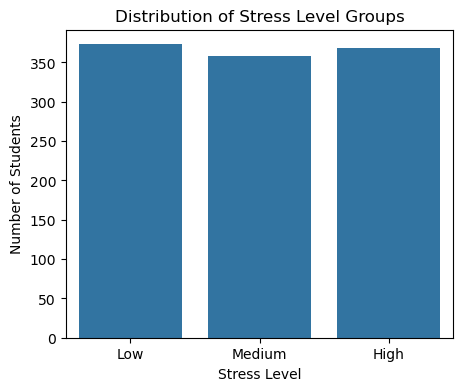

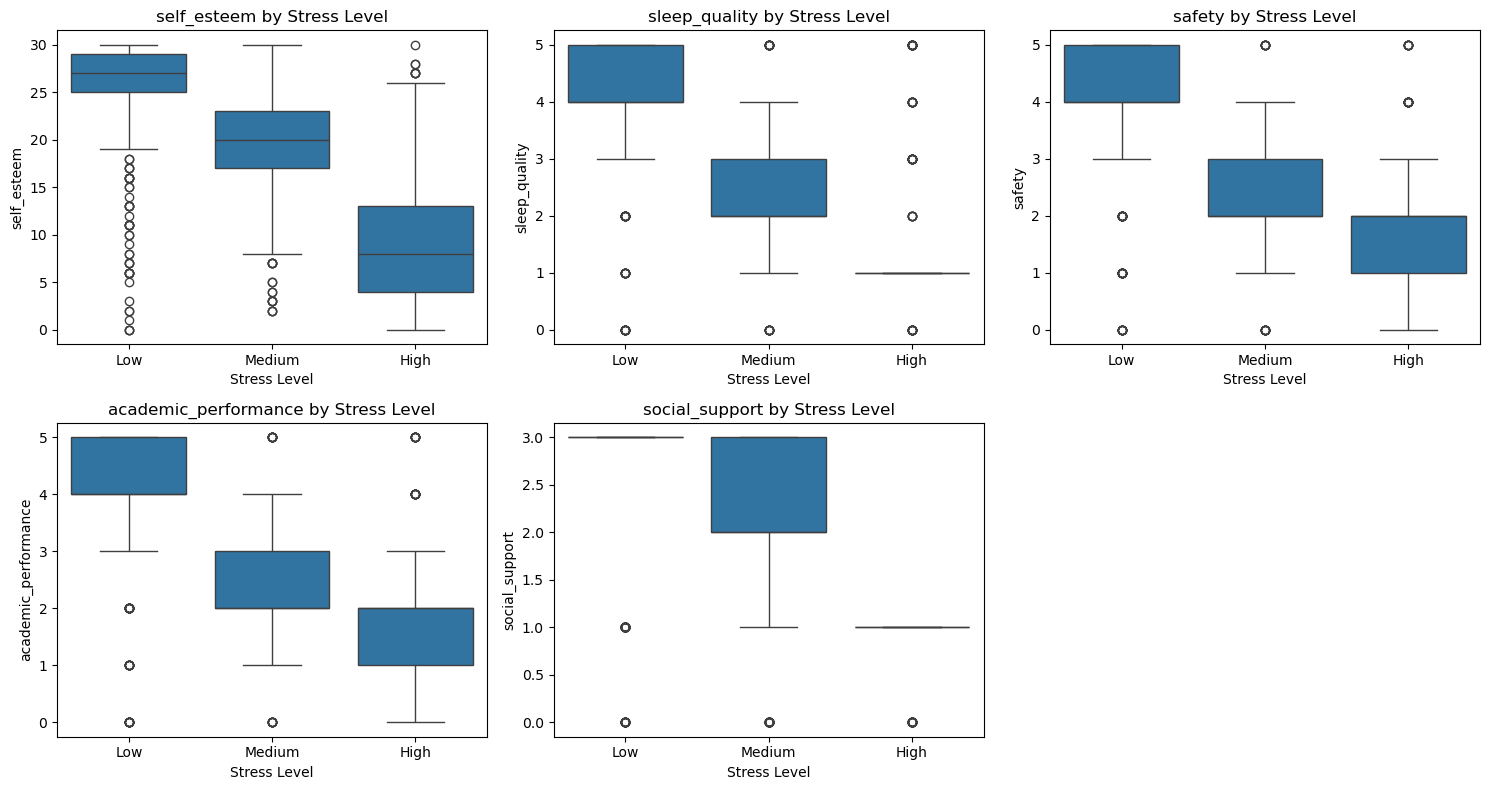

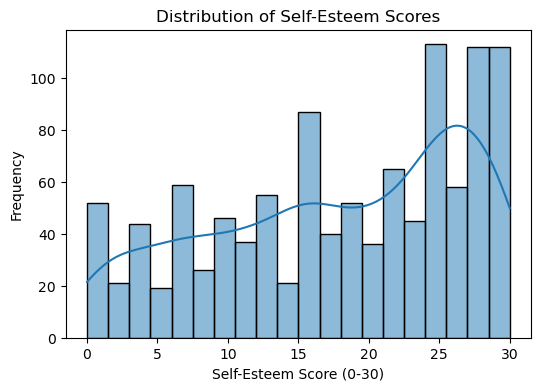

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(exist_ok=True) 

selected_vars = ["self_esteem", "sleep_quality", "safety", "academic_performance", "social_support"]

# Map numeric stress codes to readable labels for plotting only
label_map = {0: "Low", 1: "Medium", 2: "High"}
df["stress_label"] = df["stress_level"].map(label_map)
order = ["Low", "Medium", "High"]

# 1. Outcome balance
plt.figure(figsize=(5, 4))
sns.countplot(x="stress_label", data=df, order=order)
plt.title("Distribution of Stress Level Groups")
plt.xlabel("Stress Level")
plt.ylabel("Number of Students")
plt.savefig(FIGURES_DIR / "stress_level_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# 2. Boxplot of each predictor across stress groups
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(selected_vars):
    sns.boxplot(x="stress_label", y=col, data=df, order=order, ax=axes[i])
    axes[i].set_title(f"{col} by Stress Level")
    axes[i].set_xlabel("Stress Level")
    axes[i].set_ylabel(col)
axes[-1].axis("off")  # hide the unused 6th subplot
plt.tight_layout()
plt.savefig(FIGURES_DIR / "predictors_by_stress_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

# 3. Distribution shape of self_esteem (only continuous-like variable)
plt.figure(figsize=(6, 4))
sns.histplot(df["self_esteem"], kde=True, bins=20)
plt.title("Distribution of Self-Esteem Scores")
plt.xlabel("Self-Esteem Score (0-30)")
plt.ylabel("Frequency")
plt.savefig(FIGURES_DIR / "self_esteem_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Q4 - Method Selection

**Chosen method:** Kruskal-Wallis H test, applied separately for each of the 
five predictors across the three stress_level groups (Low/Medium/High).

**Why Kruskal-Wallis:**
- The outcome groups are unbalanced in scale terms: predictors are either 
  discrete Likert-type variables (4-6 categories) or a skewed quasi-continuous 
  scale (self_esteem), none of which satisfy the normality assumption required 
  by one-way ANOVA (visually confirmed in Q3; formally tested in Q5).
- Kruskal-Wallis compares distributions via ranks rather than means, making it 
  robust to non-normality and appropriate for ordinal/discrete data.
- It directly matches the group-median comparison shown in the Q3 boxplots.

**Alternatives considered and rejected as primary:**
- Independent t-test: mathematically inapplicable — requires exactly 2 groups, 
  we have 3.
- One-way ANOVA: assumptions of normality and continuous scale are violated.
- Chi-square test of independence: discards ordinal information by treating 
  categories as nominal; reserved as a secondary/sensitivity check.

**Complementary method:** Spearman rank correlation will be computed alongside 
Kruskal-Wallis, treating stress_level as an ordinal numeric variable (0/1/2), 
to summarize direction and strength of association in a single coefficient.

**Reserved for robustness check (Q7):** Jonckheere-Terpstra test, which 
exploits the known ordering of stress groups (Low < Medium < High) for 
potentially higher statistical power, will be used to confirm the Kruskal-Wallis 
conclusion.

## Q5 - Assumption Checks

**Independence:** satisfied by design — each row represents a distinct student 
with no repeated measures or known clustering.

We formally test normality (per group, per variable) and homogeneity of 
variance across groups. These checks justify the use of Kruskal-Wallis over 
one-way ANOVA and clarify how the results should be interpreted.

In [37]:
from scipy import stats

vars_to_check = ["self_esteem", "sleep_quality", "safety", "academic_performance", "social_support"]
groups = ["Low", "Medium", "High"]

# Shapiro-Wilk normality test, per variable, per group
print("=== Shapiro-Wilk Normality Test (per group) ===")
for col in vars_to_check:
    print(f"\n{col}:")
    for g in groups:
        data = df[df["stress_label"] == g][col]
        stat, p = stats.shapiro(data)
        print(f"  {g}: W={stat:.4f}, p={p:.6f}")

# Levene's test for equal variance across the three groups
print("\n=== Levene's Test for Equal Variance (across groups) ===")
for col in vars_to_check:
    low = df[df["stress_label"] == "Low"][col]
    med = df[df["stress_label"] == "Medium"][col]
    high = df[df["stress_label"] == "High"][col]
    stat, p = stats.levene(low, med, high)
    print(f"{col}: statistic={stat:.4f}, p={p:.6f}")

=== Shapiro-Wilk Normality Test (per group) ===

self_esteem:
  Low: W=0.6637, p=0.000000
  Medium: W=0.9110, p=0.000000
  High: W=0.9383, p=0.000000

sleep_quality:
  Low: W=0.6806, p=0.000000
  Medium: W=0.8158, p=0.000000
  High: W=0.4435, p=0.000000

safety:
  Low: W=0.6988, p=0.000000
  Medium: W=0.8044, p=0.000000
  High: W=0.7923, p=0.000000

academic_performance:
  Low: W=0.6774, p=0.000000
  Medium: W=0.8088, p=0.000000
  High: W=0.7509, p=0.000000

social_support:
  Low: W=0.5129, p=0.000000
  Medium: W=0.7627, p=0.000000
  High: W=0.2844, p=0.000000

=== Levene's Test for Equal Variance (across groups) ===
self_esteem: statistic=10.6393, p=0.000027
sleep_quality: statistic=18.4891, p=0.000000
safety: statistic=2.7762, p=0.062713
academic_performance: statistic=1.8435, p=0.158760
social_support: statistic=79.1872, p=0.000000


## Q6 - Primary Analysis: Estimated Relationship

For each of the five predictors, we report three layers of evidence, as 
required by the project: (1) whether a distributional difference across 
stress groups exists (Kruskal-Wallis H test), (2) how large that difference 
is (epsilon-squared effect size), and (3) the direction and strength of the 
monotonic association with 95% confidence intervals (Spearman's rho via 
Fisher z-transformation). Because five tests are run simultaneously, 
Benjamini-Hochberg FDR correction is applied to control the family-wise 
error rate.

In [40]:
from scipy import stats
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests

vars_to_test = ["self_esteem", "sleep_quality", "safety", "academic_performance", "social_support"]
n = len(df)

results = []

for col in vars_to_test:
    low = df[df["stress_label"] == "Low"][col]
    med = df[df["stress_label"] == "Medium"][col]
    high = df[df["stress_label"] == "High"][col]

    # Layer 1: Kruskal-Wallis H test
    H, p_kw = stats.kruskal(low, med, high)

    # Layer 2: Epsilon-squared effect size
    epsilon_sq = H * (n + 1) / (n**2 - 1)

    # Layer 3: Spearman correlation + 95% CI via Fisher z-transformation
    rho, p_spearman = stats.spearmanr(df[col], df["stress_level"])
    z = np.arctanh(rho)
    se = 1 / np.sqrt(n - 3)
    ci_low, ci_high = np.tanh(z - 1.96 * se), np.tanh(z + 1.96 * se)

    results.append({
        "variable": col,
        "H": H,
        "df": 2,
        "p_kw": p_kw,
        "epsilon_sq": epsilon_sq,
        "spearman_rho": rho,
        "rho_ci_low": ci_low,
        "rho_ci_high": ci_high,
        "p_spearman": p_spearman
    })

results_df = pd.DataFrame(results)

# Apply Benjamini-Hochberg FDR correction across the 5 Kruskal-Wallis p-values
rejected, p_adjusted, _, _ = multipletests(results_df["p_kw"], alpha=0.05, method="fdr_bh")
results_df["p_kw_adjusted"] = p_adjusted
results_df["significant_after_correction"] = rejected

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
print(results_df[["variable", "H", "p_kw", "p_kw_adjusted", "significant_after_correction",
                   "epsilon_sq", "spearman_rho", "rho_ci_low", "rho_ci_high"]])

               variable        H   p_kw  p_kw_adjusted  \
0           self_esteem 668.5819 0.0000         0.0000   
1         sleep_quality 636.3860 0.0000         0.0000   
2                safety 573.1239 0.0000         0.0000   
3  academic_performance 590.8496 0.0000         0.0000   
4        social_support 498.5249 0.0000         0.0000   

   significant_after_correction  epsilon_sq  spearman_rho  rho_ci_low  \
0                          True      0.6084       -0.7791     -0.8013   
1                          True      0.5791       -0.7610     -0.7848   
2                          True      0.5215       -0.7141     -0.7419   
3                          True      0.5376       -0.7283     -0.7549   
4                          True      0.4536       -0.6437     -0.6770   

   rho_ci_high  
0      -0.7548  
1      -0.7349  
2      -0.6839  
3      -0.6993  
4      -0.6077  


## Q7 - Robustness Check (Part 1): Jonckheere-Terpstra Test

While Kruskal-Wallis tests whether group distributions differ in any pattern, 
Jonckheere-Terpstra specifically tests for a monotonic trend across the 
naturally ordered stress groups (Low < Medium < High), which matches our 
theoretical expectation. Because groups are ordered as High, Medium, Low, 
Terpstra's statistic tests for a monotonic increasing trend, aligning with 
the direction we expect (predictor values increase as stress decreases).

In [43]:
import numpy as np
from scipy import stats

def jonckheere_terpstra(groups_ordered):
    """
    groups_ordered: list of arrays, in the hypothesized increasing order.
    Returns: J statistic, z-score, two-sided p-value.
    Uses the standard large-sample normal approximation (no tie correction).
    """
    k = len(groups_ordered)
    n = [len(g) for g in groups_ordered]
    N = sum(n)

    # J = sum over all pairs i<j of count(x_j > x_i), with 0.5 credit for ties
    J = 0
    for i in range(k):
        for j in range(i + 1, k):
            xi = np.asarray(groups_ordered[i])
            xj = np.asarray(groups_ordered[j])
            # broadcasting comparison: for each pair (a in xi, b in xj)
            greater = (xj[:, None] > xi[None, :]).sum()
            ties = (xj[:, None] == xi[None, :]).sum()
            J += greater + 0.5 * ties

    # Mean and variance under H0 (no tie correction)
    E_J = (N**2 - sum(ni**2 for ni in n)) / 4
    Var_J = (N**2 * (2 * N + 3) - sum(ni**2 * (2 * ni + 3) for ni in n)) / 72

    z = (J - E_J) / np.sqrt(Var_J)
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))  # two-sided

    return J, z, p_value

vars_to_test = ["self_esteem", "sleep_quality", "safety", "academic_performance", "social_support"]

# Order groups as High -> Medium -> Low to test for an INCREASING trend
# (since predictor values are expected to rise as stress level falls)
jt_results = []
for col in vars_to_test:
    high = df[df["stress_label"] == "High"][col].values
    med = df[df["stress_label"] == "Medium"][col].values
    low = df[df["stress_label"] == "Low"][col].values

    J, z, p = jonckheere_terpstra([high, med, low])
    jt_results.append({"variable": col, "J": J, "z": z, "p_value": p})

import pandas as pd
jt_df = pd.DataFrame(jt_results)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
print(jt_df)

               variable           J       z  p_value
0           self_esteem 364414.0000 28.3815   0.0000
1         sleep_quality 358253.0000 27.3073   0.0000
2                safety 344557.5000 24.9194   0.0000
3  academic_performance 348084.0000 25.5342   0.0000
4        social_support 322489.5000 21.0716   0.0000


## Q7 - Robustness Check (Part 2): Combined Multivariable Model

To assess whether each predictor has an independent association with stress 
level when controlling for the others, we fit an ordinal logistic regression 
(proportional odds model) with all five predictors simultaneously. Because 
these predictors showed moderate-to-high pairwise correlation in Q2, we first 
check Variance Inflation Factors (VIF) to confirm coefficient estimates are 
not severely distorted by multicollinearity before interpreting them.

In [46]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.miscmodels.ordinal_model import OrderedModel
import pandas as pd

vars_to_test = ["self_esteem", "sleep_quality", "safety", "academic_performance", "social_support"]
X = df[vars_to_test]

# Step 1: VIF check
vif_data = pd.DataFrame()
vif_data["variable"] = vars_to_test
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(vars_to_test))]
print("=== VIF Check ===")
print(vif_data)
print()

# Step 2: Ordinal logistic regression (proportional odds model)
y = df["stress_level"]
model = OrderedModel(y, X, distr="logit")
result = model.fit(method="bfgs", disp=False)
print("=== Ordinal Logistic Regression Summary ===")
print(result.summary())

=== VIF Check ===
               variable     VIF
0           self_esteem 12.3288
1         sleep_quality  9.4080
2                safety 10.7359
3  academic_performance 10.4427
4        social_support  8.7687

=== Ordinal Logistic Regression Summary ===
                             OrderedModel Results                             
Dep. Variable:           stress_level   Log-Likelihood:                -522.43
Model:                   OrderedModel   AIC:                             1059.
Method:            Maximum Likelihood   BIC:                             1094.
Date:                Mon, 24 Aug 2026                                         
Time:                        04:37:28                                         
No. Observations:                1100                                         
Df Residuals:                    1093                                         
Df Model:                           5                                         
                           coef   

In [47]:
ranges = {"self_esteem": 30, "sleep_quality": 5, "safety": 5, 
          "academic_performance": 5, "social_support": 3}
coefs = {"self_esteem": -0.1338, "sleep_quality": -0.7321, "safety": -0.5755,
         "academic_performance": -0.6663, "social_support": -0.2259}

for var in coefs:
    full_range_effect = coefs[var] * ranges[var]
    print(f"{var}: {full_range_effect:.3f} (log-odds change across full range)")

self_esteem: -4.014 (log-odds change across full range)
sleep_quality: -3.660 (log-odds change across full range)
safety: -2.877 (log-odds change across full range)
academic_performance: -3.332 (log-odds change across full range)
social_support: -0.678 (log-odds change across full range)


## Q7 - Robustness Summary

Four independent methods — Kruskal-Wallis, Spearman correlation, 
Jonckheere-Terpstra, and multivariable ordinal logistic regression — all 
converge on the same conclusion: self-esteem, sleep quality, safety, academic 
performance, and social support are each negatively and significantly 
associated with stress level, with a consistent relative ranking across 
methods (self-esteem and sleep quality strongest; social support weakest, 
though still significant).

**Caveat:** VIF values (8.8–12.3) indicate substantial multicollinearity among 
the five predictors. The multivariable model's individual coefficients should 
therefore be interpreted with caution — they confirm that each predictor 
retains an independent (if imprecisely estimated) association after mutual 
adjustment, but precise magnitude comparisons between predictors are less 
reliable than the univariate (Kruskal-Wallis / Spearman) results.

## Q8 - Interpretation and Limitations

**What can be concluded:** Across four independent statistical approaches, 
self-esteem, sleep quality, perceived safety, academic performance, and 
social support each show a robust, convergent, and directionally consistent 
negative association with self-reported student stress level in this sample. 
Effect sizes are large enough that the findings carry both statistical and 
practical significance, not statistical significance alone.

**What cannot be concluded:** Because the data are cross-sectional and 
observational, no causal direction can be established. reverse causality 
(e.g., stress reducing perceived sleep quality) is equally plausible. Findings 
should be interpreted strictly as "associated with," not "caused by."

**Confounding:** All variables were collected via self-report in a single 
survey administration, raising the possibility of common method bias a 
general tendency toward negative self-appraisal could inflate the observed 
associations independent of any true underlying relationship.

**Measurement limitations:** Most variables lack a documented, validated item 
set (self_esteem, resembling the Rosenberg Self-Esteem Scale, is a partial 
exception). All measures are self-reported rather than objectively verified 
(e.g., academic_performance is self-perceived, not GPA).

**Selection bias:** Sampling method, demographics, and institutional context 
of the 1,100 students are not documented, limiting generalizability.

**Statistical limitation:** Moderate-to-high multicollinearity among predictors 
(VIF 8.8-12.3) limits precise attribution of independent effect size in the 
combined model, though each predictor's association survives mutual adjustment.

**Conclusion:** Within the constraints above, the data support a strong 
association between all five Biopsychosocial dimensions and student stress, 
consistent with theoretical expectations, but do not support causal claims 
about any single factor "driving" student stress.